# BM4: projection multiplier versus step displacement

Two particles, **50 complete BM4 steps per normalized cycle, 5 cycles**: $h=0.02$, 250 steps, 251 saved states. This focused study uses `BM4Implicit` with one symmetric projection around the complete composition. It does not require a multi-method accuracy benchmark.

Here $\mu_n\in\mathbb R^2$ is each particle's **converged projection multiplier**, not magnetic moment or a Newton correction. Compare it with $\Delta z_n=z_{n+1}-z_n$ from the **same accepted step**. Both are plotted at $t_{n+1}$; there is no fictitious multiplier at $t_0$.

“Interior” and “outer” describe distance from the geometric cell centre at initialization, not proven dynamical confinement or a separatrix. Both particles start inside the periodic cell.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from diagnostics.paths import find_project_root
from dynamics import GuidingCenterDynamics
from initial_conditions import GCInitialConfiguration
from potential import load_gc2d_h5_potential
from simulation import BM4Implicit, InitialValueProblem, SimulationRequest
from studies import domain_center
from studies.bm4_vectors import run_bm4_vector_study
from visualization.bm4_vectors import plot_bm4_vectors

plt.rcParams.update({"figure.dpi": 110})

## Explicit physical and numerical parameters

Newton tolerances are tighter than the general comparison protocol because the interior multiplier can be of order $10^{-10}$; resolving its direction requires a smaller nonlinear-solver floor. This does not change the requested step size.

In [ ]:
data_path = find_project_root(Path.cwd()) / "data/potential/V1/PHI_2.h5"
magnetic_field = 1.5
characteristic_length = 0.06
mode_selection = (0, 1)
interpolation_order = 3
rho = 0.3
coupling_frequency = float(np.pi / 8)

# Deterministic offsets in cell widths, ordered (interior, outer); no random seed.
center_offsets = np.array([[0.08, -0.06], [0.35, -0.25]])
particle_labels = ("Interior particle", "Outer particle")
cycle_duration = 1.0
cycles = 5
steps_per_cycle = 50
step_count = cycles * steps_per_cycle
h = cycle_duration / steps_per_cycle
newton_absolute_tolerance = 1e-14
newton_relative_tolerance = 1e-13
newton_max_iterations = 40
jacobian_relative_step = float(np.cbrt(np.finfo(float).eps))
# A conservative display threshold, not an error bound on the multiplier.
direction_floor_in_solver_tolerances = 10.0

In [3]:
potential = load_gc2d_h5_potential(
    data_path, B=magnetic_field, characteristic_length=characteristic_length,
    indx=mode_selection, interpolation_order=interpolation_order,
)
center = np.asarray(domain_center(potential))
period = float(potential.grid.period)
initial_xy = center + center_offsets * period
configuration = GCInitialConfiguration.from_components(x=initial_xy[:, 0], y=initial_xy[:, 1])
dynamics = GuidingCenterDynamics(potential, rho=rho)
problem = InitialValueProblem(dynamics, configuration)
request = SimulationRequest.uniform(
    t_span=(0.0, cycles * cycle_duration), max_step=h, sample_count=step_count + 1,
)
method = BM4Implicit(
    coupling_frequency=coupling_frequency,
    newton_absolute_tolerance=newton_absolute_tolerance,
    newton_relative_tolerance=newton_relative_tolerance,
    newton_max_iterations=newton_max_iterations,
    newton_jacobian_method="analytic",
    newton_jacobian_relative_step=jacobian_relative_step,
)
# The display threshold is a fixed conservative cell-scale multiple of solver tolerance.
direction_floor = direction_floor_in_solver_tolerances * (
    newton_absolute_tolerance + newton_relative_tolerance * max(1.0, period, np.max(np.abs(initial_xy)))
)
assert np.all(np.abs(center_offsets) < 0.5)
assert np.linalg.norm(center_offsets[0]) < np.linalg.norm(center_offsets[1])
print(f"Steps: {step_count}; saved states: {step_count + 1}; h: {h:g}")
print(f"Direction display floor: {direction_floor:.3e}")
for label, xy in zip(particle_labels, initial_xy):
    print(f"{label}: x={xy[0]:.10f}, y={xy[1]:.10f}; radius/cell={np.linalg.norm(xy-center)/period:.3f}")

Steps: 250; saved states: 251; h: 0.02
Direction display floor: 1.895e-11
Interior particle: x=10.9327424345, y=8.2938046055; radius/cell=0.100
Outer particle: x=16.0221225333, y=4.7123889804; radius/cell=0.430


## Integrate and capture aligned vectors

Lengths use the per-particle Euclidean norm. Displacements are computed from the integrator's **unwrapped coordinates**, before any periodic display wrapping. This measures the actual step vector. The solver's global infinity norm is checked separately against the captured multipliers.

In [4]:
study = run_bm4_vector_study(problem, method, request, direction_floor=direction_floor)
assert study.mu.shape == study.delta.shape == (step_count, 2, 2)
assert study.solution.t.size == step_count + 1
assert study.solution.diagnostics["projection_solver_formulation"] == "bm4_implicit_reduced"
residual_ratio = np.asarray(study.solution.diagnostics["nonlinear_residual_norms"]) / np.asarray(study.solution.diagnostics["nonlinear_tolerances"])
assert np.max(residual_ratio) <= 1.0
print(f"Maximum accepted residual/tolerance: {np.max(residual_ratio):.3e}")

Maximum accepted residual/tolerance: 9.983e-01


## Initial geometry and trajectories
The background is the effective potential at time zero, not a time-independent invariant. Tracks use unwrapped coordinates; the dashed square marks the base periodic cell.

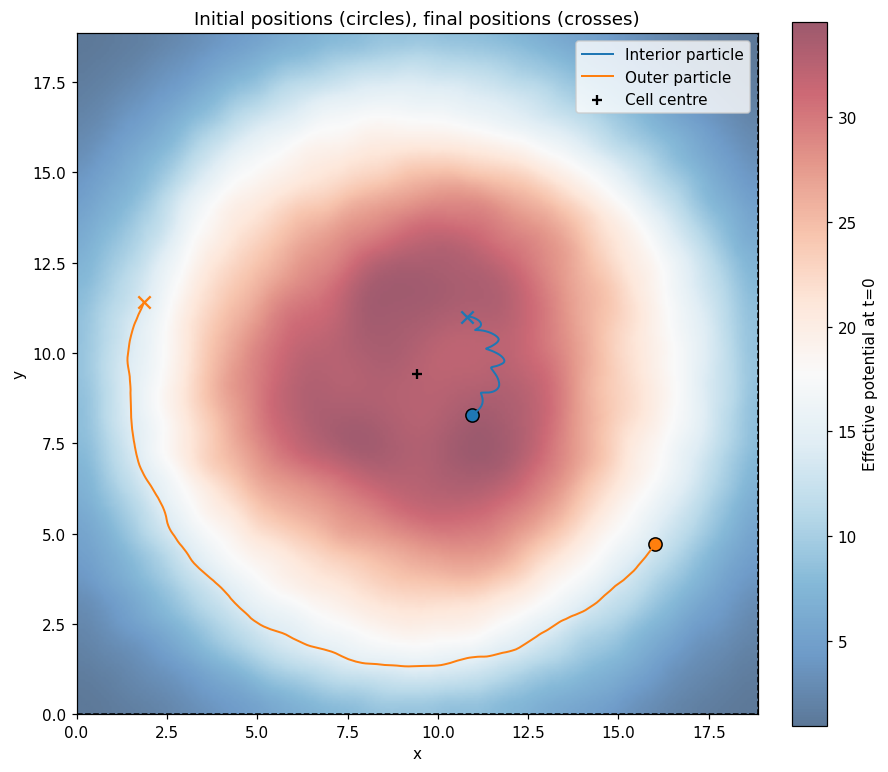

In [5]:
grid = dynamics.effective_potential.grid
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
field = ax.imshow(np.asarray(dynamics.effective_potential.evaluate_grid(0.0)).T, origin="lower",
    extent=(grid.xmin, grid.xmin+period, grid.ymin, grid.ymin+period), cmap="RdBu_r", alpha=.65)
x, y = study.solution.positions()
for p, label in enumerate(particle_labels):
    line, = ax.plot(x[p], y[p], label=label, linewidth=1.3)
    ax.scatter(x[p, 0], y[p, 0], color=line.get_color(), marker="o", s=75, edgecolor="black")
    ax.scatter(x[p, -1], y[p, -1], color=line.get_color(), marker="x", s=65)
ax.scatter(*center, marker="+", color="black", label="Cell centre")
ax.add_patch(plt.Rectangle((grid.xmin, grid.ymin), period, period, fill=False, linestyle="--"))
ax.set(xlabel="x", ylabel="y", title="Initial positions (circles), final positions (crosses)", aspect="equal")
ax.legend()
fig.colorbar(field, ax=ax, label="Effective potential at t=0")
plt.show()

## Norm and direction histories

Absolute directions use $\operatorname{atan2}(v_y,v_x)$ measured counterclockwise from $+x$, unwrapped within each contiguous resolved segment. They can still alias rotations larger than $180^\circ$ per saved step. Directions with norm below `direction_floor` are shown as gaps, not zero angles.

The signed relative angle is $\operatorname{atan2}(\sin(\theta_\mu-\theta_\Delta),\cos(\theta_\mu-\theta_\Delta))\in[-\pi,\pi]$: zero means alignment, $\pm180^\circ$ means opposition. Its absolute value is the unsigned angle between the vectors. Jumps at $\pm180^\circ$ are a branch-cut effect. The ratio $\|\mu_n\|_2/\|\Delta z_n\|_2$ measures relative scale, not a local truncation-error estimate.

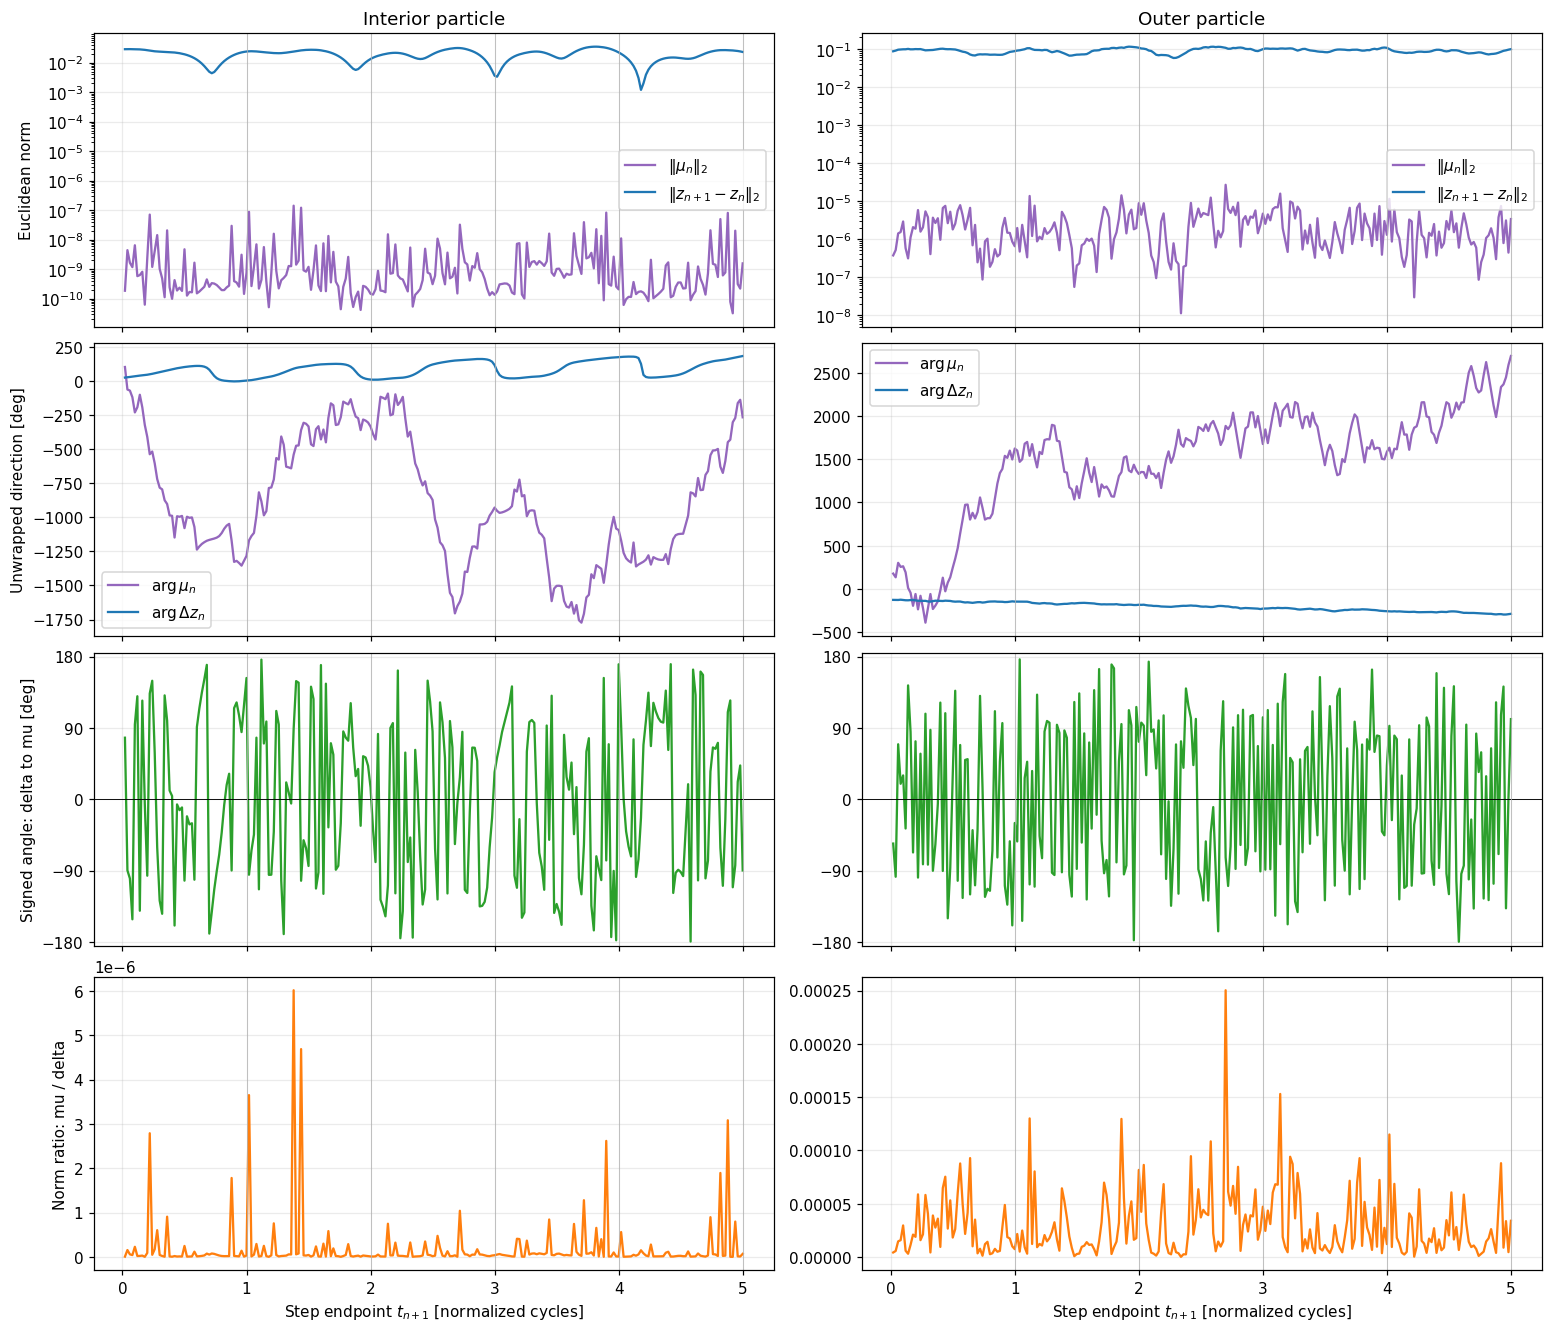

In [6]:
history_figure = plot_bm4_vectors(study, particle_labels)
plt.show()

## Computed summary
Angular summaries include only resolved pairs. No direction is inferred for a zero or unresolved multiplier.

In [7]:
rows = ["| Particle | Mean mu norm | Max mu norm | Mean step norm | Median mu/step | Median unsigned angle (deg) | Resolved angles |",
        "|---|---:|---:|---:|---:|---:|---:|"]
for p, label in enumerate(particle_labels):
    finite = np.isfinite(study.angle_difference[:, p])
    median_angle = float(np.median(np.abs(np.degrees(study.angle_difference[finite, p])))) if finite.any() else np.nan
    ratios = study.norm_ratio[:, p]
    median_ratio = float(np.median(ratios[np.isfinite(ratios)])) if np.isfinite(ratios).any() else np.nan
    rows.append(f"| {label} | {study.mu_norm[:,p].mean():.4e} | {study.mu_norm[:,p].max():.4e} | {study.delta_norm[:,p].mean():.4e} | {median_ratio:.4e} | {median_angle:.2f} | {finite.sum()}/{step_count} |")
display(Markdown("\n".join(rows)))
for p, label in enumerate(particle_labels):
    print(f"{label}: mu norm first/last = {study.mu_norm[0,p]:.5e} / {study.mu_norm[-1,p]:.5e}; "
          f"step norm first/last = {study.delta_norm[0,p]:.5e} / {study.delta_norm[-1,p]:.5e}")

| Particle | Mean mu norm | Max mu norm | Mean step norm | Median mu/step | Median unsigned angle (deg) | Resolved angles |
|---|---:|---:|---:|---:|---:|---:|
| Interior particle | 4.7581e-09 | 1.4275e-07 | 1.9385e-02 | 3.1599e-08 | 92.57 | 250/250 |
| Outer particle | 2.7423e-06 | 2.6670e-05 | 9.0019e-02 | 1.7683e-05 | 90.56 | 250/250 |

Interior particle: mu norm first/last = 1.87955e-10 / 1.58468e-09; step norm first/last = 2.85292e-02 / 2.29940e-02
Outer particle: mu norm first/last = 3.70908e-07 / 3.34624e-06; step norm first/last = 8.64636e-02 / 9.84128e-02
